In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
%matplotlib inline


In [84]:
# Read data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [85]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [86]:
# remove column name spaces of each DataFrame 
remove_spaces(df)
    
    

In [87]:
# create df with only Air temp data of each Station
df_Tair = df["Tair"]
df_Tair

Date
2014-10-01 00:00:00    22.130
2014-10-01 01:00:00    21.680
2014-10-01 02:00:00    22.210
2014-10-01 03:00:00    22.410
2014-10-01 04:00:00    22.300
                        ...  
2021-08-31 20:00:00    29.100
2021-08-31 21:00:00    29.595
2021-08-31 22:00:00    27.730
2021-08-31 23:00:00    27.300
2021-09-01 00:00:00    26.210
Name: Tair, Length: 60649, dtype: float64

In [88]:
# Exclude data with dates before 2015
reindex_df_Tair = df_Tair[(df_Tair.index > "2014-12-31 23:00")]

In [89]:
# Fill nan values
reindex_df_Tair.replace([np.inf, -np.inf], np.nan, inplace=True)
reindex_df_Tair.fillna(reindex_df_Tair.mean(), inplace=True)

reindex_df_Tair

Date
2015-01-01 00:00:00    -1.090
2015-01-01 01:00:00    -1.038
2015-01-01 02:00:00    -0.981
2015-01-01 03:00:00    -0.814
2015-01-01 04:00:00    -0.805
                        ...  
2021-08-31 20:00:00    29.100
2021-08-31 21:00:00    29.595
2021-08-31 22:00:00    27.730
2021-08-31 23:00:00    27.300
2021-09-01 00:00:00    26.210
Name: Tair, Length: 58441, dtype: float64

In [90]:
update_df_Tair = reindex_df_Tair.resample('D').mean()

Text(0, 0.5, 'Tair Data in Celsius')

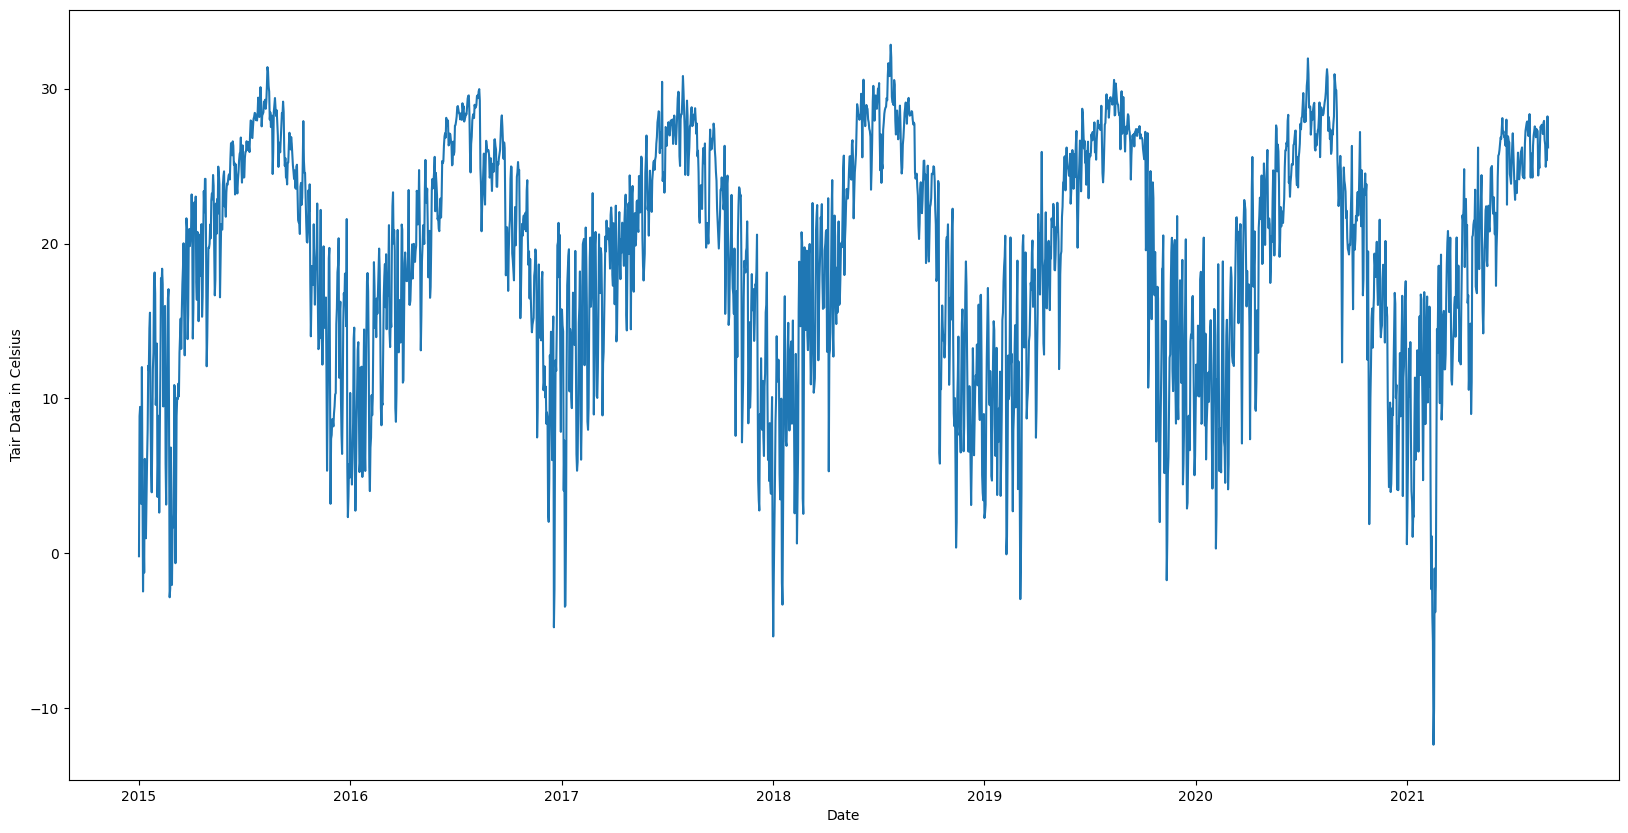

In [91]:
fig, ax = plt.subplots()

ax.plot(update_df_Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Tair Data in Celsius')

    

In [92]:
# stationarity test for stations
ad_fuller_result = adfuller(update_df_Tair)

print(f'ADF Statistic: {ad_fuller_result[0]}')
print(f'p-value: {ad_fuller_result[1]}\n')

ADF Statistic: -3.64049414863975
p-value: 0.0050324217159780525



In [105]:
# Train/Test Split
train = update_df_Tair[:'2019-12-31 23:00']
test = update_df_Tair['2019-12-31 23:00':]

In [106]:
# Defining optimize_SARIMAX function
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int)->pd.DataFrame:

    results=[]
    
    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(
            endog,
            exog,
            order=(order[0], d, order[1]),
            seasonal_order=(order[2], D, order[3], s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
        
        results.append([order, model.aic])
    
    result_df=pd.DataFrame(results)
    result_df.columns = ['(p, q, P, Q)', 'AIC']
    
    # Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [107]:
# Define range of values for p, q, P, and Q

ps= range(0, 2, 1)
qs= range(0, 2, 1)
Ps= range(0, 2, 1)
Qs= range(0, 2, 1)

# Create list of all unique combinations
order_list = list(product(ps, qs, Ps, Qs))

# Set constants
d=0
D=0
s=12

In [108]:
# Find the (p, d, q) (P, D, Q)m comination with the lowest AIC
SARIMA_result_df = optimize_SARIMAX(train, None, order_list, d, D, s)

  0%|          | 0/16 [00:00<?, ?it/s]

In [109]:
result_array=SARIMA_result_df.to_numpy()
optimal_parameters = result_array[0]
print(result_array)

[[(1, 1, 1, 1) 9494.559653932392]
 [(1, 0, 1, 1) 9518.742003319843]
 [(1, 1, 0, 0) 9541.25561683731]
 [(1, 1, 1, 0) 9542.609230394819]
 [(1, 1, 0, 1) 9542.664637565496]
 [(1, 0, 0, 0) 9548.473151256087]
 [(1, 0, 1, 0) 9549.910817335915]
 [(1, 0, 0, 1) 9549.954758609883]
 [(0, 1, 1, 1) 10024.602980446332]
 [(0, 1, 1, 0) 10395.90200251422]
 [(0, 0, 1, 1) 11127.553683207025]
 [(0, 0, 1, 0) 11389.938593318086]
 [(0, 1, 0, 1) 12636.515553240106]
 [(0, 1, 0, 0) 14048.400513203025]
 [(0, 0, 0, 1) 14521.074098982142]
 [(0, 0, 0, 0) 16230.302812696696]]


In [110]:
# Fit optimal model to study its residuals
SARIMA_model = SARIMAX(train, order=(result_array[0][0][0], 0, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], 12), enforce_invertibility=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)
print(SARIMA_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                               Tair   No. Observations:                 1826
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -4742.353
Date:                            Tue, 13 Jun 2023   AIC                           9494.706
Time:                                    16:14:25   BIC                           9522.255
Sample:                                01-01-2015   HQIC                          9504.868
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8898      0.013     67.139      0.000       0.864       0.916
ma.L1          0.1815      0.021   

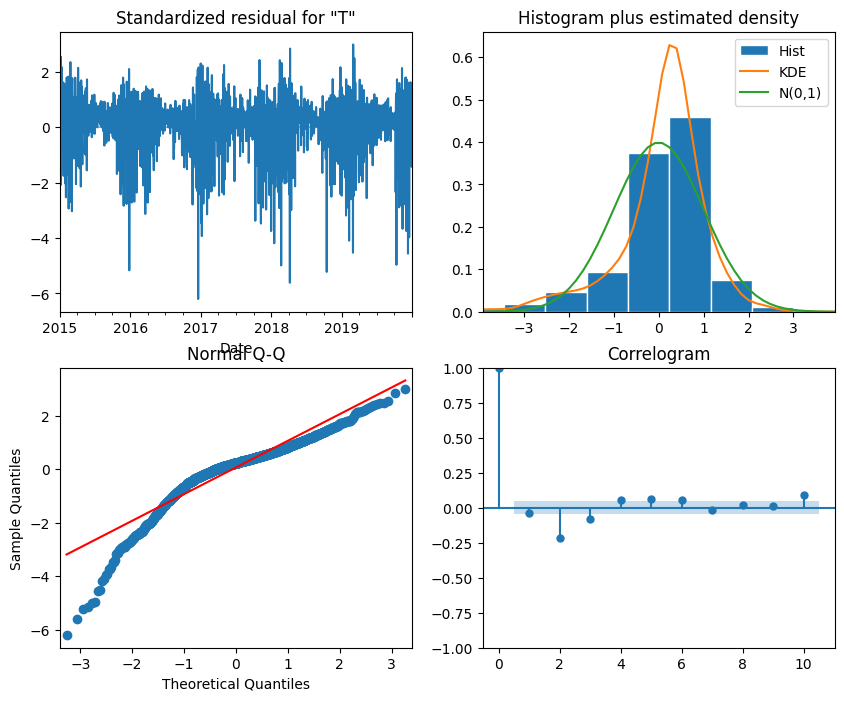

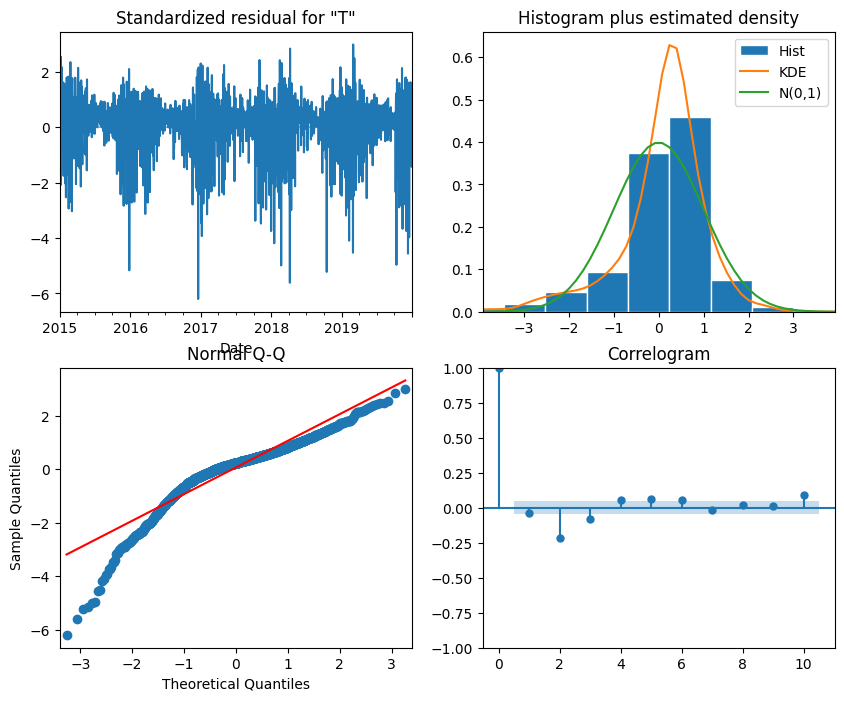

In [111]:
# Plot residual's diagnostics
SARIMA_model_fit.plot_diagnostics(figsize=(10,8));

In [112]:
# Run the Ljung-Box test
residuals = SARIMA_model_fit.resid
lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 3, 1))
    
# Print p-values
print(pvalue)


lb_pvalue


In [113]:
# Function to preform rolling forcasts
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:

    total_len = train_len + horizon
    end_idx = train_len
    
    if method == 'last_season':
        pred_last_season=[]
        
        for i in range(train_len, total_len, window):
            last_season = update_df_Tair[i-window:i].values
            pred_last_season.extend(last_season)
            
        return pred_last_season
    
    elif method == 'SARIMA':
        pred_SARIMA = []
        
        for i in range(train_len, total_len, window):
            model = SARIMAX(update_df_Tair[:i], order=(result_array[0][0][0], 0, result_array[0][0][1]), seasonal_order = (result_array[0][0][2], 0, result_array[0][0][3], 12), simple_differencing=True)
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
        
        return pred_SARIMA

In [114]:
pred_df = update_df_Tair['2015-09-17 23:00':]

In [ ]:
# Define length of training set, horizon of forecast, and the window of forecast
TRAIN_LEN = 1679
HORIZON = 365
WINDOW = 73



# Preform rolling forecast with the naive seasonal baseline
pred_df_array = rolling_forecast(update_df_Tair, TRAIN_LEN, HORIZON, WINDOW, 'last_season')
SARIMA_df_array = rolling_forecast(update_df_Tair, TRAIN_LEN, HORIZON, WINDOW, 'SARIMA')

#Display the predictions
print(SARIMA_df_array)
print(pred_df_array)

In [ ]:
# mean squared error or r squared